--- Initial Model Evaluation ---
Logistic Regression Accuracy: 1.0000
Decision Tree Accuracy: 1.0000
Random Forest Accuracy: 1.0000

--- Starting Grid Search for Random Forest ---

Best Parameters found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}

Final Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



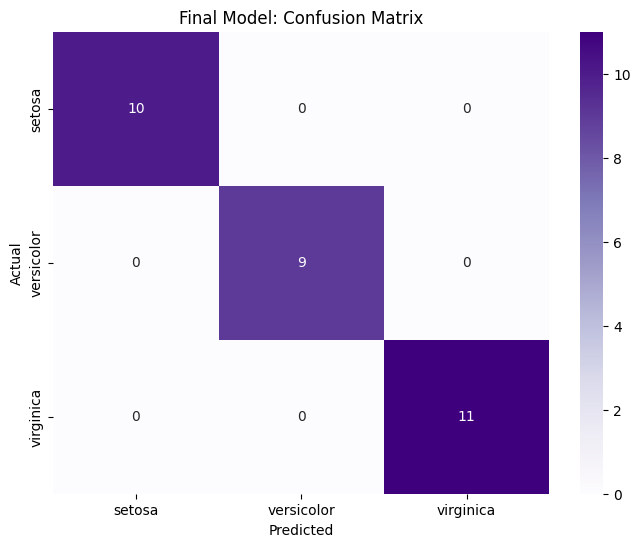

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the dataset (iris)
# Make sure iris.csv is in the same folder as this notebook
df = pd.read_csv('iris.csv')

# 2. Preprocessing (Objectives: Handle categorical variables & Feature scaling)
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])

X = df.drop(['species', 'species_encoded'], axis=1)
y = df['species_encoded']

# Feature Scaling: Essential for models like Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. Train and Test Multiple Models (Objective: Multiple classification models)
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

print("--- Initial Model Evaluation ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# 5. Hyperparameter Tuning (Objective: Grid search)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

print("\n--- Starting Grid Search for Random Forest ---")
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# 6. Final Evaluation (Objective: Accuracy, Precision, Recall, F1-score)
final_preds = best_model.predict(X_test)
print(f"\nBest Parameters found: {grid_search.best_params_}")
print("\nFinal Classification Report:")
print(classification_report(y_test, final_preds, target_names=le.classes_))

# 7. Visualization (Objective: Matplotlib/Seaborn)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, cmap='Purples', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Final Model: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()